# Customer Segmentation Analysis using RFM and K-Means Clustering

## Objective
The objective of this project is to segment customers of an e-commerce business into distinct groups based on purchasing behavior using RFM analysis and K-Means clustering. These customer segments can help businesses design targeted marketing strategies and improve customer retention.

## Tools and Technologies
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn
- Jupyter Notebook

# Import Libraries

In [78]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings('ignore')

In [79]:
import os

print(os.listdir(r"C:\Users\hp\Downloads\archive (8)"))

['ecommerce_customer_data_custom_ratios.csv', 'ecommerce_customer_data_large.csv']


# Load Dataset

In [80]:
df = pd.read_csv(
    r"C:\Users\hp\Downloads\archive (8)\ecommerce_customer_data_custom_ratios.csv"
)

df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1


# Dataset Inspection

In [81]:
df.shape


(250000, 13)

In [82]:
df.columns

Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
       'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age',
       'Returns', 'Customer Name', 'Age', 'Gender', 'Churn'],
      dtype='object')

In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202404 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB


In [84]:
df.isnull().sum()

Customer ID                  0
Purchase Date                0
Product Category             0
Product Price                0
Quantity                     0
Total Purchase Amount        0
Payment Method               0
Customer Age                 0
Returns                  47596
Customer Name                0
Age                          0
Gender                       0
Churn                        0
dtype: int64

In [85]:
df.describe()

,Customer ID,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Churn
count,250000.00000,250000.000000,250000.000000,250000.000000,250000.000000,202404.000000,250000.000000,250000.000000
mean,25004.03624,254.659512,2.998896,2725.370732,43.940528,0.497861,43.940528,0.199496
std,14428.27959,141.568577,1.414694,1442.933565,15.350246,0.499997,15.350246,0.399622
min,1.00000,10.000000,1.000000,100.000000,18.000000,0.000000,18.000000,0.000000
25%,12497.75000,132.000000,2.000000,1477.000000,31.000000,0.000000,31.000000,0.000000
50%,25018.00000,255.000000,3.000000,2724.000000,44.000000,0.000000,44.000000,0.000000
75%,37506.00000,377.000000,4.000000,3974.000000,57.000000,1.000000,57.000000,0.000000
max,50000.00000,500.000000,5.000000,5350.000000,70.000000,1.000000,70.000000,1.000000


# Data Cleaning

In this step, duplicate records are removed, missing values are handled, and the purchase date is converted into datetime format to prepare the dataset for analysis.

In [107]:
# Remove duplicate rows
df = df.drop_duplicates()

# Check shape again
df.shape

(250000, 13)

In [87]:
df['Returns'] = df['Returns'].fillna(0)

df.isnull().sum()

Customer ID              0
Purchase Date            0
Product Category         0
Product Price            0
Quantity                 0
Total Purchase Amount    0
Payment Method           0
Customer Age             0
Returns                  0
Customer Name            0
Age                      0
Gender                   0
Churn                    0
dtype: int64

In [88]:
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

In [89]:
df['Purchase Date'].head()

0   2020-09-08 09:38:32
1   2022-03-05 12:56:35
2   2022-05-23 18:18:01
3   2020-11-12 13:13:29
4   2020-11-27 17:55:11
Name: Purchase Date, dtype: datetime64[ns]

In [90]:
df.describe()

,Customer ID,Purchase Date,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Churn
count,250000.00000,250000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
mean,25004.03624,2021-11-06 23:31:24.372304384,254.659512,2.998896,2725.370732,43.940528,0.403076,43.940528,0.199496
min,1.00000,2020-01-01 00:15:00,10.000000,1.000000,100.000000,18.000000,0.000000,18.000000,0.000000
25%,12497.75000,2020-12-02 19:33:23.249999872,132.000000,2.000000,1477.000000,31.000000,0.000000,31.000000,0.000000
50%,25018.00000,2021-11-06 13:10:59,255.000000,3.000000,2724.000000,44.000000,0.000000,44.000000,0.000000
75%,37506.00000,2022-10-11 03:42:32.750000128,377.000000,4.000000,3974.000000,57.000000,1.000000,57.000000,0.000000
max,50000.00000,2023-09-15 12:24:08,500.000000,5.000000,5350.000000,70.000000,1.000000,70.000000,1.000000
std,14428.27959,NaN,141.568577,1.414694,1442.933565,15.350246,0.490517,15.350246,0.399622


In [91]:
df.describe(include='object')

,Product Category,Payment Method,Customer Name,Gender
count,250000,250000,250000,250000
unique,4,4,39920,2
top,Clothing,Credit Card,Michael Smith,Female
freq,75052,100486,107,125560


### Exploratory Data Analysis

In [92]:
average_purchase = df['Total Purchase Amount'].mean()

print("Average Purchase Value:", round(average_purchase,2))

Average Purchase Value: 2725.37


In [93]:
purchase_frequency = df.groupby('Customer ID').size()

purchase_frequency.describe()

count    49673.000000
mean         5.032915
std          2.206427
min          1.000000
25%          3.000000
50%          5.000000
75%          6.000000
max         17.000000
dtype: float64

In [94]:
customer_lifetime = df.groupby('Customer ID')['Total Purchase Amount'].sum()

customer_lifetime.describe()

count    49673.000000
mean     13716.559962
std       6840.208557
min        110.000000
25%       8719.000000
50%      13026.000000
75%      17966.000000
max      55339.000000
Name: Total Purchase Amount, dtype: float64

## RFM Analysis

RFM stands for:

- **Recency** – How recently a customer made a purchase.
- **Frequency** – How often a customer makes purchases.
- **Monetary** – Total amount spent by the customer.

These three features are used for customer segmentation.

In [95]:
snapshot_date = df['Purchase Date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg({
    'Purchase Date': lambda x: (snapshot_date - x.max()).days,
    'Customer ID': 'count',
    'Total Purchase Amount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
1,58,1,3491
2,299,3,7988
3,89,8,22587
4,127,4,8715
5,171,8,12524


# Standardization

Since RFM features have different scales, StandardScaler is applied to normalize the data before performing K-Means clustering

In [96]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

rfm_scaled[:5]

array([[-0.82685846, -1.82782207, -1.49493437],
       [ 0.15273062, -0.92137006, -0.83749166],
       [-0.70085323,  1.34475996,  1.29682147],
       [-0.5463952 , -0.46814406, -0.73120728],
       [-0.36754906,  1.34475996, -0.17434731]])

## Elbow Method 
The Elbow Method is used to determine the optimal number of clusters by observing the point where the WCSS begins to decrease more slowly.

In [97]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

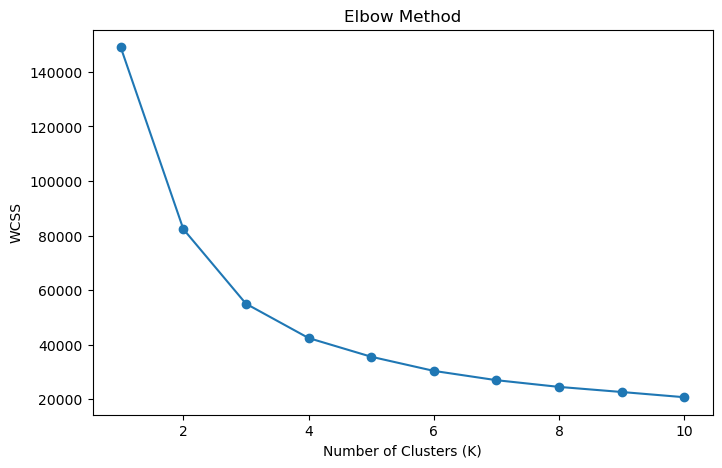

In [98]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')

plt.show()

# K-Means Clustering

In [99]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [100]:
rfm.head()

,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
1,58,1,3491,2
2,299,3,7988,2
3,89,8,22587,0
4,127,4,8715,2
5,171,8,12524,1


In [101]:
rfm['Cluster'].value_counts()

Cluster
1    18723
2    14912
0     8389
3     7649
Name: count, dtype: int64

In [102]:
cluster_profile = rfm.groupby('Cluster').mean()

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,136.843843,8.440577,24494.153654
1,183.652246,5.715804,15614.061368
2,194.014351,3.332216,8292.908731
3,719.847954,2.939600,7825.245392


# visualization

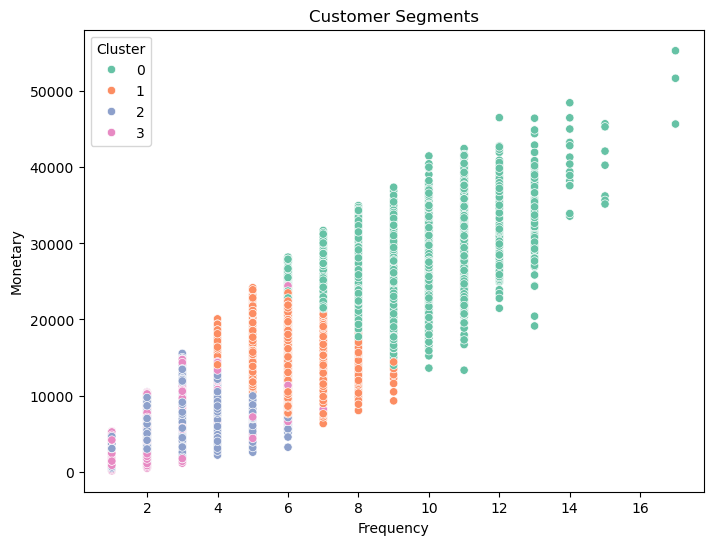

In [103]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='Set2'
)

plt.title("Customer Segments")
plt.show()

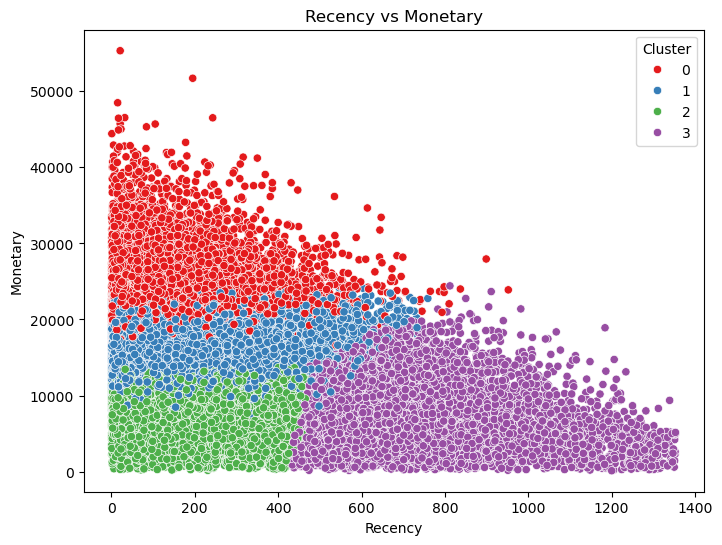

In [104]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette='Set1'
)

plt.title("Recency vs Monetary")
plt.show()

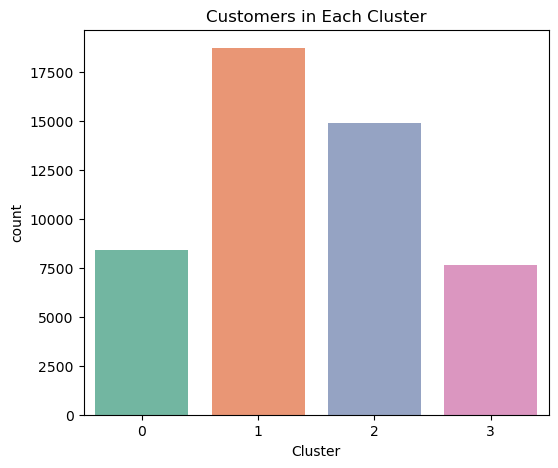

In [105]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=rfm,
    x='Cluster',
    palette='Set2'
)

plt.title("Customers in Each Cluster")
plt.show()

In [106]:
cluster_profile.round(2)

,Recency,Frequency,Monetary
Cluster,,,
0,136.84,8.44,24494.15
1,183.65,5.72,15614.06
2,194.01,3.33,8292.91
3,719.85,2.94,7825.25


# Insights

Cluster 0 – High-Value Customers
Highest average purchase amount.
High purchase frequency.
Recently active customers.
Recommendation: Reward with loyalty programs, exclusive offers, and VIP memberships.

Cluster 1 – Regular Customers
Moderate purchase frequency.
Moderate spending.
Fairly recent activity.
Recommendation: Encourage repeat purchases through personalized recommendations and promotional discounts.

Cluster 2 – Occasional Customers
Lower spending.
Lower purchase frequency.
Less active than Clusters 0 and 1.
Recommendation: Use targeted promotions and product recommendations to increase engagement.

Cluster 3 – Inactive Customers
Very high Recency (customers have not purchased for a long time).
Lowest purchase frequency.
Lowest spending.
Recommendation: Run win-back campaigns, special discounts, and reminder emails to re-engage these customers.

# conclusion

In this project, customers were segmented using RFM analysis and K-Means clustering.

The Elbow Method was used to determine the optimal number of clusters (K = 4). Customers were grouped based on Recency, Frequency, and Monetary values.

The resulting segments identified high-value, regular, occasional, and inactive customers. These insights can help businesses design personalized marketing strategies, improve customer retention, and increase overall sales.